# PCA Exploratory Analysis
We conduct exploratory analysis using PCA to examine the factor structure of the crypto return data (70 assets over 2022 to 2024 inclusive). Specifically, we decompose the return covariance matrix into its principal components and show how the first three components explain the cross-sectional variance over time. We then examine the relationship between PCA and the OLS approach by plotting the PC1 loadings for BTC and ETH, the two assets used as market proxies in the OLS residual construction. Finally, we present the mean absolute PC1 loadings for the top 20 assets, which contextualises the finding that PC1 explains approximately 50-70% of return variance yet exhibits near-uniform loadings across the universe, consistent with the common variation in returns being spread roughly equally across all assets rather than being concentrated in or driven by one dominant asset.

In [1]:
cd -q ../../

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.pca.pca import calc_pca_loadings, calc_resid_pca

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

## Data

In [3]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets = pd.read_parquet(rets_parquet_path)
px = pd.read_parquet(px_parquet_path)

In [4]:
px = px.loc[:"20241231"]
rets = rets.loc[:"20241231"]

### Rolling Explained Variance Ratio

Below we show the rolling explained variance ratio for the first three principal components of the crypto asset return matrix. PC1 accounts for 50-70% of the explained variance throughout the sample, while PC2 and PC3 each account for less than 5% individually, strongly suggesting that crypto returns are driven by a single dominant common factor, consistent with the well-documented high cross-sectional correlation of crypto assets. PC1 is therefore a natural proxy for the market component of returns, and the residual after removing it can reasonably be interpreted as the idiosyncratic component. Notably, PC1 explained variance increases from approximately 50% in early 2022 to 60-70% from mid-2024, reflecting rising cross-sectional correlation over the period, likely driven by the increased influence of macro factors following the Bitcoin ETF approval in January 2024. Despite the dominance of PC1, we sweep across 1, 2 and 3 components in our parameter optimisation to confirm empirically which configuration best isolates the mean-reverting idiosyncratic signal.

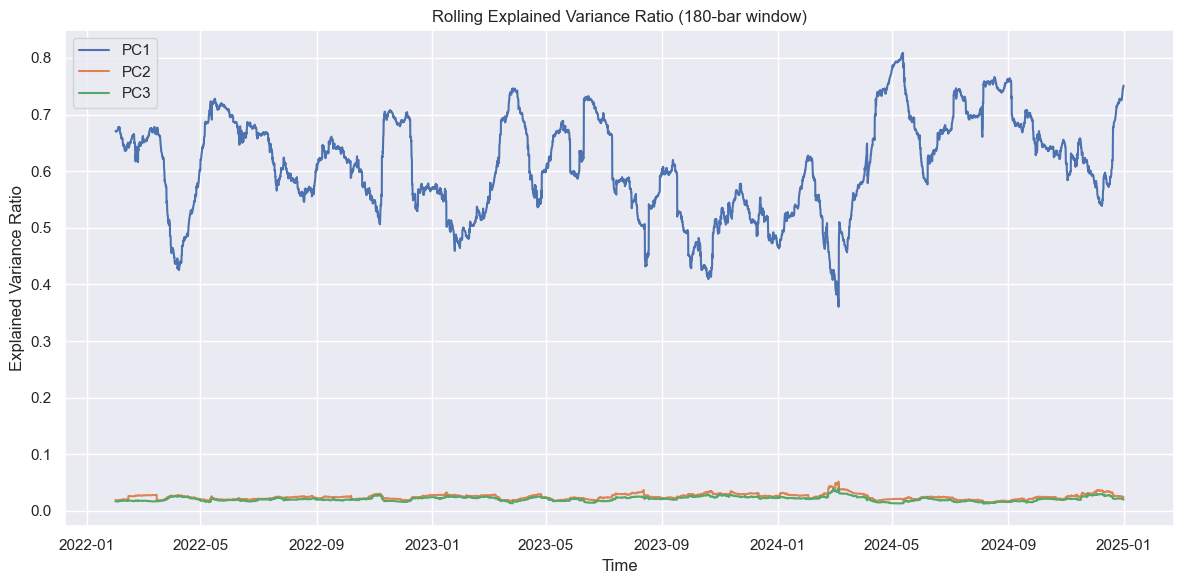

In [5]:
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 30 * BARS_PER_DAY

df = calc_resid_pca(rets, n_components=3, window_size=window_size, plot_variance=True)

## Loadings

To contextualise the OLS results within the PCA framework, we examine the rolling PC1 loadings for BTC and ETH. Both assets exhibit similar loading magnitudes throughout the sample (approximately 0.12-0.13), and neither stands out as a dominant contributor to PC1. This is consistent with the diffuse factor structure identified above: PC1 represents a near-equal-weight market factor rather than a BTC- or ETH-led hierarchy.

To confirm this, we examine the mean absolute PC1 loadings for the top 20 contributing assets. ETH ranks 4th while BTC does not appear in the top 20, suggesting BTC has slightly lower co-movement with the broader altcoin universe than average, likely reflecting its distinct narrative drivers which occasionally decorrelate it from the altcoin market. The assets ranking above BTC and ETH are predominantly high-beta altcoins, suggesting PC1 captures a broad risk-on/risk-off factor across the altcoin universe rather than a pure BTC-driven market factor.

This finding has an important implication for the OLS analysis: since loadings are approximately uniform across the universe, the choice of market proxy is unlikely to be critical, and any sufficiently liquid asset would serve as a reasonable benchmark. This explains why OLS with ETH and OLS with BTC yield similar in-sample performance, and why both perform comparably to single-component PCA.

In [9]:
loadings_df = calc_pca_loadings(rets, window_size=180, n_components=1)

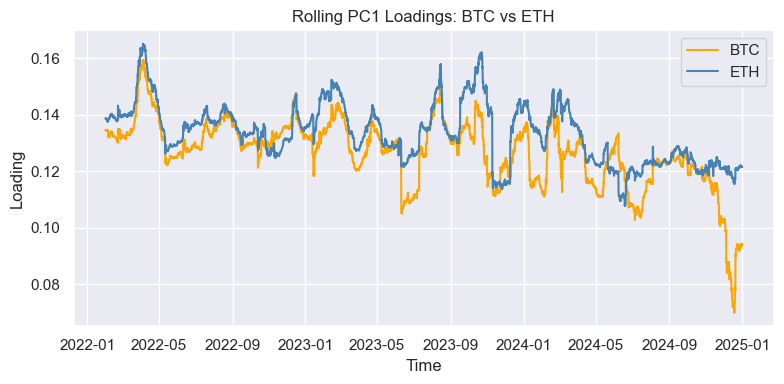

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loadings_df["BTCUSDT"], label="BTC", color="orange")
ax.plot(loadings_df["ETHUSDT"], label="ETH", color="steelblue")
ax.set_title("Rolling PC1 Loadings: BTC vs ETH")
ax.set_ylabel("Loading")
ax.set_xlabel("Time")
ax.legend()
plt.tight_layout()
plt.show()

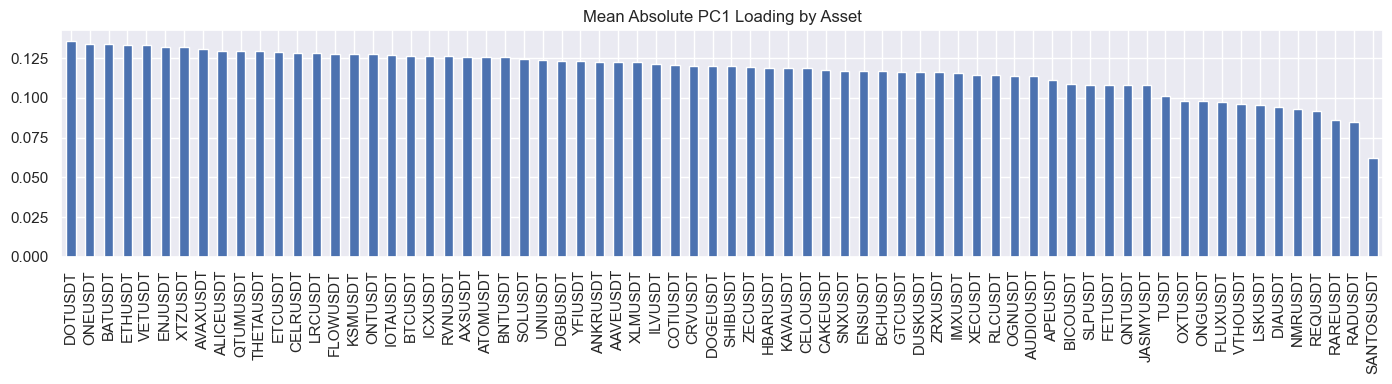

In [7]:
mean_loadings = loadings_df.abs().mean().sort_values(ascending=False)
mean_loadings.plot(kind="bar", figsize=(14, 4), title="Mean Absolute PC1 Loading by Asset")
plt.tight_layout()
plt.show()